# Worksheet 8

## - 23MS121 
## - Manish Behera

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Q1 


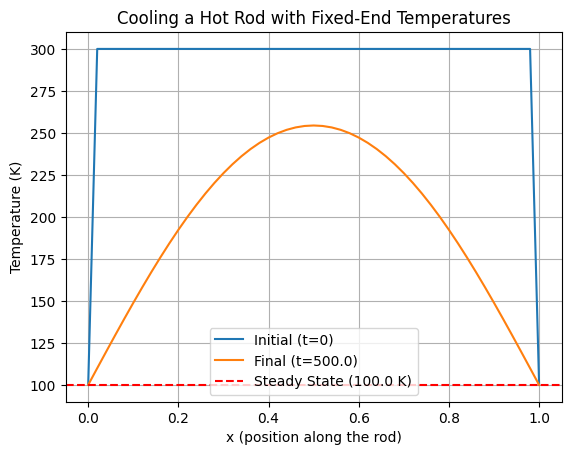

In [ ]:
def thomas_solve(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

# -------------------------------
# Parameters
# -------------------------------
L      = 1.0      # Physical length of the rod (m). Determined by the problem.
Nx     = 51       # Number of spatial grid points. A trade-off between accuracy and computation time.
dx     = L/(Nx-1) # Spatial step size (m). Calculated from L and Nx.
alpha  = 1e-4     # Thermal diffusivity of the material (m^2/s). A physical property.
dt     = 0.1      # Time step (s). Smaller dt gives more temporal accuracy but requires more steps.
Nt     = 5000     # Number of time steps to simulate. Total time = Nt * dt.
r      = alpha*dt/dx**2 # Courant number. For accuracy, should ideally be of order 1 or less.

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T0 = 100.0
T_left = T0
T_right= T0

# Initial condition
T_init = 300.0
T = np.full(Nx, T_init)
T[0] = T_left
T[-1] = T_right


# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += (r/2) * T_old[0] + (r/2) * T_left
    RHS[-1]   += (r/2) * T_old[-1] + (r/2) * T_right

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
plt.plot(x, time_history[0], label='Initial (t=0)')
plt.plot(x, T, label=f'Final (t={Nt*dt})')
plt.xlabel('x (position along the rod)')
plt.ylabel('Temperature (K)')
plt.title('Cooling a Hot Rod with Fixed-End Temperatures')
plt.axhline(y=T0, color='r', linestyle='--', label=f'Steady State ({T0} K)')
plt.legend()
plt.grid(True)
plt.show()


## Q2

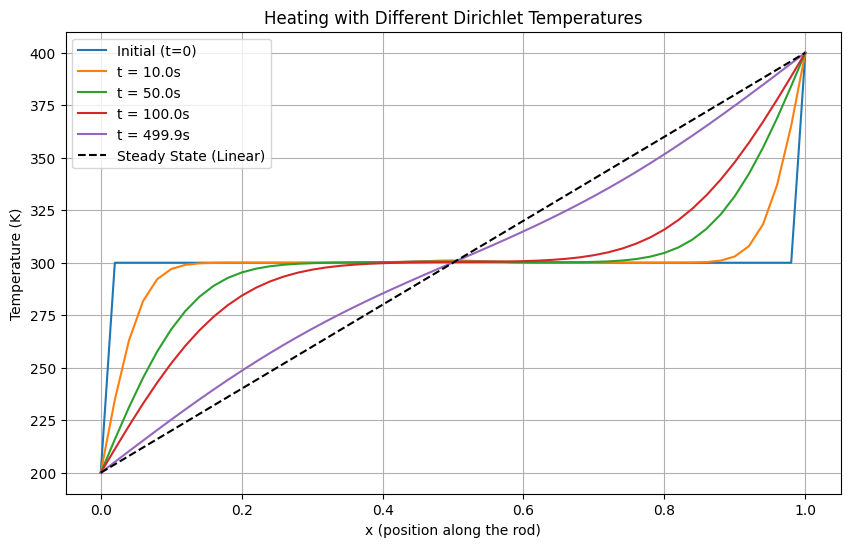

In [8]:
# -------------------------------
# Parameters
# -------------------------------
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 200.0
T_right= 400.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
peak_amplitude = 1.0 # As per u(x,0) = 300 + exp(...)
for i in range(Nx):
    T[i] += peak_amplitude * np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))
T[0] = T_left
T[-1] = T_right


# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]
plot_times = [0, 100, 500, 1000, Nt-1] # Time steps to plot
time_snapshots = {0: T.copy()}

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary contributions
    RHS[0]    += (r/2) * (T_old[0] + T_left)
    RHS[-1]   += (r/2) * (T_old[-1] + T_right)

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    if (n + 1) in plot_times:
        time_snapshots[n + 1] = T.copy()

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot initial condition
plt.plot(x, time_snapshots[0], label='Initial (t=0)')

# Plot intermediate snapshots
for t_step, temp_profile in time_snapshots.items():
    if t_step != 0:
        plt.plot(x, temp_profile, label=f't = {(t_step)*dt:.1f}s')

# Plot the linear steady-state solution
T_steady = np.linspace(T_left, T_right, Nx)
plt.plot(x, T_steady, 'k--', label='Steady State (Linear)')

plt.xlabel('x (position along the rod)')
plt.ylabel('Temperature (K)')
plt.title('Heating with Different Dirichlet Temperatures')
plt.legend()
plt.grid(True)
plt.show()